# European swaptions and annuity pricing

Construct a forward swap and price the right to pay or receive fixed using its discounted annuity.

[Chapter notes](README.md) · [All topics](../../README.md)

## Research design

A payer swaption gives the right to enter a payer swap at a fixed coupon; a receiver swaption gives the opposite right. Its underlying is a forward-starting swap, so the option price depends on the forward par rate and the discounted fixed-leg annuity, not on one bond yield.

The example uses one-year European exercise into a five-year USD swap with annual fixed and quarterly synthetic term-floating payments. Notional is 100, accrual is Actual/360, dates are Modified Following, fixing lag is zero, and the core illustrative projection and OIS discount curves remain distinct. `VanillaSwap`, `EuropeanExercise`, `Swaption` and `BlackSwaptionEngine` make the full contract-to-engine path visible. Settlement is physical; there is no cash-annuity convention to infer.

For annuity $A=N\sum_i\alpha_iD_i$, forward swap rate $F$, strike $K$ and expiry $T$, the payer price is $A[F\Phi(d_1)-K\Phi(d_2)]$, with $d_1=\log(F/K)/(\sigma\sqrt T)+\sigma\sqrt T/2$. The notebook reconstructs the annuity from fixed coupons, checks the forward swap PV against $A(F-K)$, compares QuantLib to a direct Black calculation, and verifies payer–receiver parity at three strikes. A quote update reprices the same at-the-money contract at several volatilities.

The 20% input is a flat lognormal swap-rate volatility, not 20 basis points of normal volatility. Positive rates are required by this unshifted Black example. No smile, volatility-surface calibration, Bermudan exercise or dynamic hedging is claimed. See [QuantLib swaption engines](https://quantlib-python-docs.readthedocs.io/en/latest/pricing_engines/swaptions.html) and the [Black engine implementation](https://github.com/lballabio/QuantLib/blob/master/ql/pricingengines/swaption/blackswaptionengine.hpp).

In [1]:
from pathlib import Path
import sys
candidates = [Path.cwd(), *Path.cwd().parents]
ROOT = next(p for p in candidates if (p / 'research' / 'pricing.py').is_file())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import QuantLib as ql
from IPython.display import display
from research.common import RESULTS, check_hashes
from research.pricing import DATE, CAL, valuation_date, curves, fixture
plt.rcParams.update({'figure.dpi':110, 'axes.spines.top':False, 'axes.spines.right':False,
                     'axes.grid':True, 'grid.alpha':.18, 'font.size':11})
# Verify the core fixture, source and saved-output vintage before reading any summary.
check_hashes()
# Every chapter uses explicit illustrative assumptions; never a hidden data download.


## Calculation and independent checks

All inputs below are illustrative. Assertions check the identities discussed in the chapter.

In [2]:
from scipy.stats import norm
with valuation_date():
    discount, projection, _ = curves()
    dh = ql.YieldTermStructureHandle(discount)
    index = ql.IborIndex('IllustrativeSwaption3M', ql.Period('3M'), 0, ql.USDCurrency(),
                        CAL, ql.ModifiedFollowing, False, ql.Actual360(),
                        ql.YieldTermStructureHandle(projection))
    exercise_date = CAL.advance(DATE, ql.Period('1Y'))
    maturity = CAL.advance(exercise_date, ql.Period('5Y'))
    def schedule(tenor):
        return ql.Schedule(exercise_date, maturity, ql.Period(tenor), CAL,
                           ql.ModifiedFollowing, ql.ModifiedFollowing,
                           ql.DateGeneration.Forward, False)
    fixed, floating = schedule('1Y'), schedule('3M')
    def underlying(side, strike):
        swap = ql.VanillaSwap(side, 100., fixed, strike, ql.Actual360(),
                             floating, index, 0., ql.Actual360(), ql.ModifiedFollowing, True)
        swap.setPricingEngine(ql.DiscountingSwapEngine(dh))
        return swap
    probe = underlying(ql.VanillaSwap.Payer, .04)
    forward = probe.fairRate()
    annuity = sum(100*ql.as_coupon(c).accrualPeriod()*discount.discount(c.date())
                  for c in probe.fixedLeg())
    assert abs(annuity-abs(probe.fixedLegBPS())/1e-4) < 1e-10
    vol_quote = ql.SimpleQuote(.20)
    engine = ql.BlackSwaptionEngine(dh, ql.QuoteHandle(vol_quote), ql.Actual365Fixed())
    expiry = ql.Actual365Fixed().yearFraction(DATE, exercise_date)
    def option(side, strike):
        instrument = ql.Swaption(underlying(side, strike), ql.EuropeanExercise(exercise_date),
                                ql.Settlement.Physical)
        instrument.setPricingEngine(engine)
        return instrument
    rows = []
    for strike in [forward-.005, forward, forward+.005]:
        payer = option(ql.VanillaSwap.Payer, strike)
        receiver = option(ql.VanillaSwap.Receiver, strike)
        stddev = vol_quote.value()*np.sqrt(expiry)
        d1 = np.log(forward/strike)/stddev+stddev/2; d2 = d1-stddev
        manual = annuity*(forward*norm.cdf(d1)-strike*norm.cdf(d2))
        linear_pv = annuity*(forward-strike)
        assert abs(payer.NPV()-manual) < 1e-10
        assert abs(payer.NPV()-receiver.NPV()-linear_pv) < 1e-10
        assert abs(underlying(ql.VanillaSwap.Payer,strike).NPV()-linear_pv) < 1e-10
        rows.append({'strike_pct':strike*100, 'payer_PV':payer.NPV(),
                     'receiver_PV':receiver.NPV(), 'manual_payer_PV':manual,
                     'payer_minus_receiver':payer.NPV()-receiver.NPV()})
    prices = pd.DataFrame(rows)
    atm = option(ql.VanillaSwap.Payer, forward)
    values = []
    try:
        for vol in [.05, .10, .20, .30, .40]:
            vol_quote.setValue(vol)
            values.append({'Black_vol_pct':vol*100, 'ATM_payer_PV':atm.NPV()})
    finally:
        vol_quote.setValue(.20)
    volatility = pd.DataFrame(values)
    assert (np.diff(volatility.ATM_payer_PV) > 0).all()
    print(f'Forward par rate {100*forward:.6f}%; discounted annuity per 100 {annuity:.6f}')
display(prices.round(6)); display(volatility.round(6))

Forward par rate 3.909210%; discounted annuity per 100 441.318468


,strike_pct,payer_PV,receiver_PV,manual_payer_PV,payer_minus_receiver
0,3.40921,2.678041,0.471449,2.678041,2.206592
1,3.90921,1.374225,1.374225,1.374225,0.000000
2,4.40921,0.614624,2.821216,0.614624,-2.206592


,Black_vol_pct,ATM_payer_PV
0,5.0,0.344093
1,10.0,0.687971
2,20.0,1.374225
3,30.0,2.057057
4,40.0,2.734788


## Economic relationship

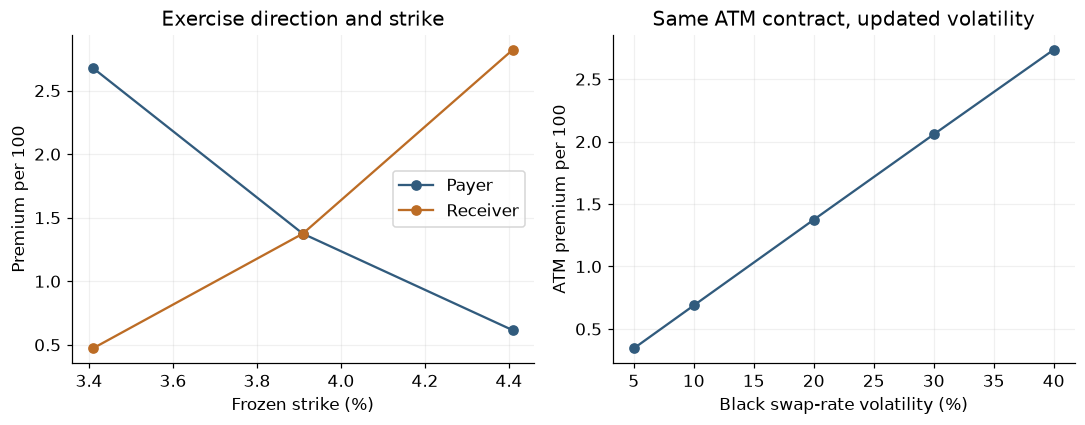

In [3]:
fig, axes = plt.subplots(1,2,figsize=(10,4))
axes[0].plot(prices.strike_pct, prices.payer_PV, marker='o', label='Payer', color='#315b7d')
axes[0].plot(prices.strike_pct, prices.receiver_PV, marker='o', label='Receiver', color='#bc6c25')
axes[0].set(xlabel='Frozen strike (%)', ylabel='Premium per 100', title='Exercise direction and strike')
axes[0].legend()
axes[1].plot(volatility.Black_vol_pct, volatility.ATM_payer_PV, marker='o', color='#315b7d')
axes[1].set(xlabel='Black swap-rate volatility (%)', ylabel='ATM premium per 100', title='Same ATM contract, updated volatility')
fig.tight_layout(); plt.show()

## Interpretation

The discounted annuity and forward rate reproduce QuantLib's European price. Payer–receiver parity equals the forward swap value, and volatility quote changes propagate to the same option contract.